### 获取以及清理数据

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [43]:
data=pd.read_csv('C:/Users/asus/Desktop/数据挖掘与预测/数据集.csv')

In [44]:
data=data.dropna()
data1=data
data1

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2 years,2,...,9.0,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8 years,0,...,0.0,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0
3,3,11000.0,3,7.26,340.96,A,A4,46854.0,10+ years,1,...,16.0,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0
5,5,11000.0,3,7.99,344.65,A,A5,51727.0,7 years,0,...,1.0,48.0,2.0,3.0,2.0,19.0,0.0,0.0,0.0,0.0
6,6,2050.0,3,7.69,63.95,A,A4,180083.0,9 years,0,...,11.0,3.0,10.0,18.0,3.0,12.0,0.0,0.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799995,799995,25000.0,3,14.49,860.41,C,C4,2659.0,7 years,1,...,6.0,2.0,12.0,13.0,10.0,14.0,0.0,0.0,0.0,3.0
799996,799996,17000.0,3,7.90,531.94,A,A4,29205.0,10+ years,0,...,15.0,16.0,2.0,19.0,2.0,7.0,0.0,0.0,0.0,0.0
799997,799997,6000.0,3,13.33,203.12,C,C3,2582.0,10+ years,1,...,4.0,26.0,4.0,10.0,4.0,5.0,0.0,0.0,1.0,4.0
799998,799998,19200.0,3,6.92,592.14,A,A4,151.0,10+ years,0,...,10.0,6.0,12.0,22.0,8.0,16.0,0.0,0.0,0.0,5.0


In [46]:
del data1['id']
data1.columns=['贷款金额','贷款期限','贷款利率','分期付款金额','贷款等级','贷款等级之子级','就业职称','就业年限','房屋所有情况','年收入','验证状态','贷款发放的月份','是否违约',
               '贷款目的','邮政编码','地区编码','债务收入比','2年内违约次数'
               ,'fico所属的下限范围','fico所属的上限范围','未结信用额度数量','贬损公共记录的数量','公开记录清除的数量','信贷周转余额合计','循环额度利用率'
               ,'当前的信用额度总数','贷款的初始列表状态','申请类型','借款人最早报告的信用额度开立的月份','贷款名称','策略是否公开','n0', 'n1', 'n2', 'n3',
               'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14']
def lianghua(x):
    if x['贷款等级']=='A':
        return 7
    if x['贷款等级']=='B':
        return 6
    if x['贷款等级']=='C':
        return 5
    if x['贷款等级']=='D':
        return 4
    if x['贷款等级']=='E':
        return 3
    if x['贷款等级']=='F':
        return 2
    if x['贷款等级']=='G':
        return 1
data1.loc[:,'贷款等级']=data1.apply(lianghua,axis=1)
del data1['贷款等级之子级']
data1['就业年限']=data1['就业年限'].replace({'< 1 year':'1 year','10+ years':'10 years'}).str.split(' ',expand=True)[0].astype('int64')

In [47]:
whether_default=data1['是否违约']
del data1['是否违约']

In [48]:
data1.columns

Index(['贷款金额', '贷款期限', '贷款利率', '分期付款金额', '贷款等级', '就业职称', '就业年限', '房屋所有情况',
       '年收入', '验证状态', '贷款发放的月份', '贷款目的', '邮政编码', '地区编码', '债务收入比', '2年内违约次数',
       'fico所属的下限范围', 'fico所属的上限范围', '未结信用额度数量', '贬损公共记录的数量', '公开记录清除的数量',
       '信贷周转余额合计', '循环额度利用率', '当前的信用额度总数', '贷款的初始列表状态', '申请类型',
       '借款人最早报告的信用额度开立的月份', '贷款名称', '策略是否公开', 'n0', 'n1', 'n2', 'n3', 'n4',
       'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14'],
      dtype='object')

### 筛选指标
* 1.主观得筛选一些指标，有一些特征明显结果不好
* 2.用模型进行客观的指标筛选

In [49]:
del data1['就业职称']
del data1['验证状态']
del data1['贷款发放的月份']
del data1['邮政编码']
del data1['地区编码']
del data1['贷款的初始列表状态']
del data1['借款人最早报告的信用额度开立的月份']
del data1['贷款名称']

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [29]:
std=StandardScaler()
data1=std.fit_transform(data1)

In [ ]:
rfc=RandomForestClassifier()
rfc.fit(data1,whether_default)

In [70]:
for labels,scores in zip(list(data1.columns),list(rfc.feature_importances_)):
    print(labels+':'+'\t',scores)

贷款金额:	 0.044417337261234494
贷款期限:	 0.01602721396940701
贷款利率:	 0.06796185764916228
分期付款金额:	 0.05747858097605005
贷款等级:	 0.03575482830998528
就业年限:	 0.02684481610280388
房屋所有情况:	 0.011075013122670103
年收入:	 0.05518939596433948
贷款目的:	 0.01821072620919263
债务收入比:	 0.0652654943579655
2年内违约次数:	 0.011317727427532166
fico所属的下限范围:	 0.028677709438892113
fico所属的上限范围:	 0.02898180129402077
未结信用额度数量:	 0.0293628609980044
贬损公共记录的数量:	 0.008476780380866583
公开记录清除的数量:	 0.005685229968442885
信贷周转余额合计:	 0.0621638411459642
循环额度利用率:	 0.059180624859579485
当前的信用额度总数:	 0.043965589667479106
申请类型:	 0.0020665385975193683
策略是否公开:	 0.0
n0:	 0.013896549295482927
n1:	 0.023095105147132314
n2:	 0.018752692627319077
n3:	 0.018586437157437522
n4:	 0.02615412403770648
n5:	 0.034979316863378636
n6:	 0.03989032470256448
n7:	 0.028425196065057286
n8:	 0.03884696912599035
n9:	 0.019085331988882626
n10:	 0.029388939699702115
n11:	 0.00015372878162896238
n12:	 0.0006195332512754909
n13:	 0.00437871168004467
n14:	 0.025643071875285334

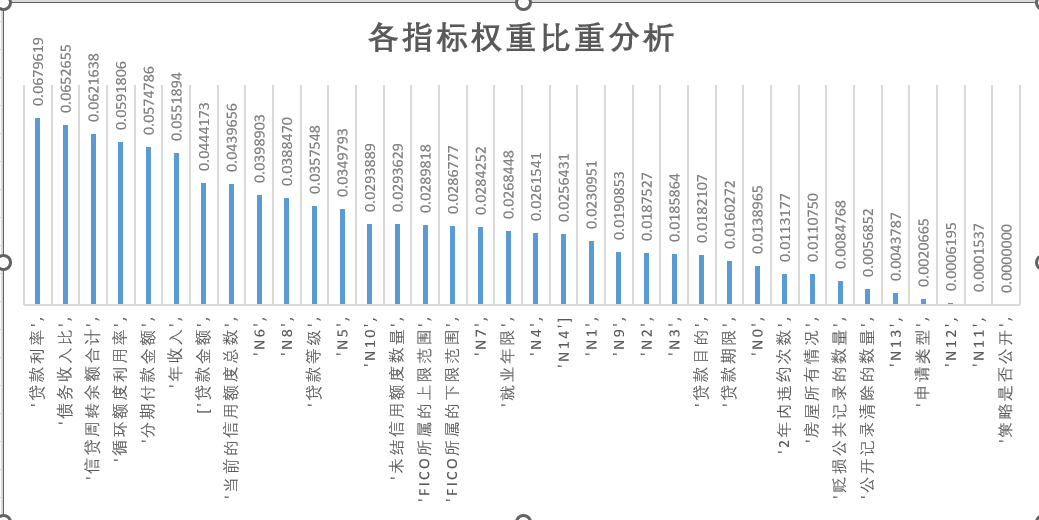

### 选择平均数以上的指标0.027（平均数）以上的的指标

In [84]:
data=pd.read_csv('C:/Users/asus/Desktop/数据挖掘与预测/数据集.csv')
data=data.dropna()
del data['id']
data.columns=['贷款金额','贷款期限','贷款利率','分期付款金额','贷款等级','贷款等级之子级','就业职称','就业年限','房屋所有情况','年收入','验证状态','贷款发放的月份','是否违约',
               '贷款目的','邮政编码','地区编码','债务收入比','2年内违约次数'
               ,'fico所属的下限范围','fico所属的上限范围','未结信用额度数量','贬损公共记录的数量','公开记录清除的数量','信贷周转余额合计','循环额度利用率'
               ,'当前的信用额度总数','贷款的初始列表状态','申请类型','借款人最早报告的信用额度开立的月份','贷款名称','策略是否公开','n0', 'n1', 'n2', 'n3',
               'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14']
def lianghua(x):
    if x['贷款等级']=='A':
        return 7
    if x['贷款等级']=='B':
        return 6
    if x['贷款等级']=='C':
        return 5
    if x['贷款等级']=='D':
        return 4
    if x['贷款等级']=='E':
        return 3
    if x['贷款等级']=='F':
        return 2
    if x['贷款等级']=='G':
        return 1
data.loc[:,'贷款等级']=data.apply(lianghua,axis=1)
del data['贷款等级之子级']
data['就业年限']=data['就业年限'].replace({'< 1 year':'1 year','10+ years':'10 years'}).str.split(' ',expand=True)[0].astype('int64')

In [75]:
data.columns

Index(['贷款金额', '贷款期限', '贷款利率', '分期付款金额', '贷款等级', '就业职称', '就业年限', '房屋所有情况',
       '年收入', '验证状态', '贷款发放的月份', '是否违约', '贷款目的', '邮政编码', '地区编码', '债务收入比',
       '2年内违约次数', 'fico所属的下限范围', 'fico所属的上限范围', '未结信用额度数量', '贬损公共记录的数量',
       '公开记录清除的数量', '信贷周转余额合计', '循环额度利用率', '当前的信用额度总数', '贷款的初始列表状态', '申请类型',
       '借款人最早报告的信用额度开立的月份', '贷款名称', '策略是否公开', 'n0', 'n1', 'n2', 'n3', 'n4',
       'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14'],
      dtype='object')

In [85]:
data=data[['贷款发放的月份','贷款利率','n5','n10','未结信用额度数量','fico所属的上限范围','fico所属的下限范围','n7'
           ,'信贷周转余额合计','循环额度利用率','分期付款金额','年收入','贷款金额','当前的信用额度总数','n6','n8','贷款等级'
           ,'债务收入比','是否违约']]

In [87]:
data.to_excel('C:/Users/asus/Desktop/数据挖掘与预测/最终数据集.xlsx')

### 模型的建立

In [145]:
ultimate_data=pd.read_csv('C:/Users/asus/Desktop/数据挖掘与预测/最终数据集.csv',encoding="gbk")
ultimate_data

,Unnamed: 0,贷款发放的月份,贷款利率,n5,n10,未结信用额度数量,fico所属的上限范围,fico所属的下限范围,n7,信贷周转余额合计,循环额度利用率,分期付款金额,年收入,贷款金额,当前的信用额度总数,n6,n8,贷款等级,债务收入比,是否违约
0,3203,2012-08-01,10.16,8,7,7,709,705,4,2326,45.6,161.72,40000.0,5000,24,7,15,6,15.96,1
1,5454,2012-08-01,10.16,7,8,8,729,725,7,20749,46.1,388.11,62000.0,12000,23,9,14,6,19.80,0
2,5546,2012-08-01,20.49,12,12,12,719,715,11,79238,61.0,803.02,100024.0,30000,25,4,17,3,20.68,1
3,7353,2012-08-01,13.11,14,14,14,694,690,12,16879,80.4,674.94,64000.0,20000,30,11,19,6,15.19,0
4,9887,2012-08-01,12.12,19,16,17,739,735,11,19064,50.2,379.19,79000.0,17000,47,17,27,6,17.12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686190,793301,2018-12-01,8.81,4,5,5,694,690,3,7620,49.8,697.66,80000.0,22000,15,4,10,7,12.21,0
686191,794237,2018-12-01,10.33,10,16,16,694,690,13,11148,34.0,116.73,46000.0,3600,26,9,17,6,41.79,0
686192,794433,2018-12-01,23.40,8,12,12,664,660,10,16707,52.2,581.84,70000.0,14950,20,4,14,3,13.66,0
686193,795227,2018-12-01,10.33,5,7,7,774,770,7,774,3.6,518.76,40000.0,16000,11,0,11,6,0.75,0


In [146]:
del ultimate_data['Unnamed: 0']

In [147]:
data_2018=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2018-'),:]
data_2017=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2017-'),:]
data_2016=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2016-'),:]
data_2015=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2015-'),:]
data_2014=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2014-'),:]
data_2013=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2013-'),:]
data_2012=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2012-'),:]

In [148]:
del data_2018['贷款发放的月份']
del data_2017['贷款发放的月份']
del data_2016['贷款发放的月份']
del data_2015['贷款发放的月份']
del data_2014['贷款发放的月份']
del data_2013['贷款发放的月份']
del data_2012['贷款发放的月份']

In [149]:
y_2018=data_2018['是否违约']
y_2017=data_2017['是否违约']
y_2016=data_2016['是否违约']
y_2015=data_2015['是否违约']
y_2014=data_2014['是否违约']
y_2013=data_2013['是否违约']
y_2012=data_2012['是否违约']

In [150]:
del data_2018['是否违约']
del data_2017['是否违约']
del data_2016['是否违约']
del data_2015['是否违约']
del data_2014['是否违约']
del data_2013['是否违约']
del data_2012['是否违约']

In [151]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
data_2012=std.fit_transform(data_2012)
data_2013=std.fit_transform(data_2013)
data_2014=std.fit_transform(data_2014)
data_2015=std.fit_transform(data_2015)
data_2016=std.fit_transform(data_2016)

In [152]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(data_2012,y_2012)
y_2013_predict=model.predict(data_2013)
model.fit(data_2013,y_2013)
y_2014_predict=model.predict(data_2014)
model.fit(data_2014,y_2014)
y_2015_predict=model.predict(data_2015)
model.fit(data_2015,y_2015)
y_2016_predict=model.predict(data_2016)
model.fit(data_2016,y_2016)
y_2017_predict=model.predict(data_2017)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [153]:
y_predict=np.hstack([y_2013_predict,y_2014_predict,y_2015_predict,y_2016_predict,y_2017_predict])
y_true=np.hstack([y_2013,y_2014,y_2015,y_2016,y_2017])

In [154]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true,y_predict)

array([[448665,  66097],
       [103167,  24002]], dtype=int64)

In [155]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
precision_score(y_true,y_predict)
recall_score(y_true,y_predict)
f1_score(y_true,y_predict)

0.22094371927757422

In [156]:
from sklearn.metrics import precision_score
precision_score(y_true,y_predict)

0.2663958534500938

In [157]:
from sklearn.metrics import recall_score
recall_score(y_true,y_predict)

0.18874096674504007

In [158]:
from sklearn.metrics import f1_score
f1_score(y_true,y_predict)

0.22094371927757422

In [159]:
y_2013_scores=model.decision_function(data_2013)
y_2014_scores=model.decision_function(data_2014)
y_2015_scores=model.decision_function(data_2015)
y_2016_scores=model.decision_function(data_2016)
y_2017_scores=model.decision_function(data_2017)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [160]:
y_scores=np.hstack([y_2013_scores,y_2014_scores,y_2015_scores,y_2016_scores,y_2017_scores])

In [161]:
y_label=np.hstack([y_2013,y_2014,y_2015,y_2016,y_2017])

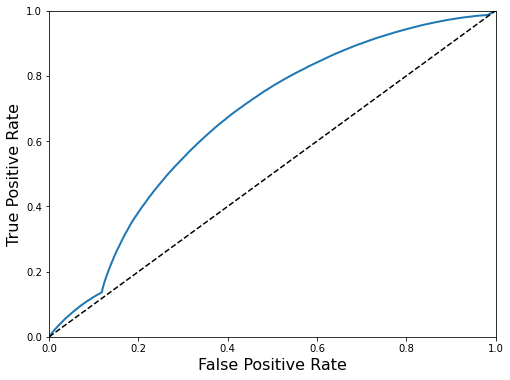

In [162]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_label,y_scores)
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)

plt.figure(figsize=(8, 6))
plot_roc_curve(fpr, tpr)
plt.show()

In [163]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_label, y_scores)

0.6670091271452813

### 比较不同模型下的auc曲线

In [113]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [166]:
ultimate_data=pd.read_csv('C:/Users/asus/Desktop/数据挖掘与预测/最终数据集.csv',encoding="gbk")
del ultimate_data['Unnamed: 0']

data_2018=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2018-'),:]
data_2017=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2017-'),:]
data_2016=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2016-'),:]
data_2015=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2015-'),:]
data_2014=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2014-'),:]
data_2013=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2013-'),:]
data_2012=ultimate_data.loc[ultimate_data['贷款发放的月份'].str.startswith('2012-'),:]
del data_2018['贷款发放的月份']
del data_2017['贷款发放的月份']
del data_2016['贷款发放的月份']
del data_2015['贷款发放的月份']
del data_2014['贷款发放的月份']
del data_2013['贷款发放的月份']
del data_2012['贷款发放的月份']
y_2018=data_2018['是否违约']
y_2017=data_2017['是否违约']
y_2016=data_2016['是否违约']
y_2015=data_2015['是否违约']
y_2014=data_2014['是否违约']
y_2013=data_2013['是否违约']
y_2012=data_2012['是否违约']
del data_2018['是否违约']
del data_2017['是否违约']
del data_2016['是否违约']
del data_2015['是否违约']
del data_2014['是否违约']
del data_2013['是否违约']
del data_2012['是否违约']
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
data_2012=std.fit_transform(data_2012)
data_2013=std.fit_transform(data_2013)
data_2014=std.fit_transform(data_2014)
data_2015=std.fit_transform(data_2015)
data_2016=std.fit_transform(data_2016)

from xgboost.sklearn import XGBClassifier
model=XGBClassifier()

model.fit(data_2012,y_2012)
y_2013_predict=model.predict(data_2013)
model.fit(data_2013,y_2013)
y_2014_predict=model.predict(data_2014)
model.fit(data_2014,y_2014)
y_2015_predict=model.predict(data_2015)
model.fit(data_2015,y_2015)
y_2016_predict=model.predict(data_2016)
model.fit(data_2016,y_2016)
y_2017_predict=model.predict(data_2017)
y_predict=np.hstack([y_2013_predict,y_2014_predict,y_2015_predict,y_2016_predict,y_2017_predict])
y_true=np.hstack([y_2013,y_2014,y_2015,y_2016,y_2017])
y_2013_scores=model.predict_proba(data_2013)[:,1]
y_2014_scores=model.predict_proba(data_2014)[:,1]
y_2015_scores=model.predict_proba(data_2015)[:,1]
y_2016_scores=model.predict_proba(data_2016)[:,1]
y_2017_scores=model.predict_proba(data_2017)[:,1]
y_scores6=np.hstack([y_2013_scores,y_2014_scores,y_2015_scores,y_2016_scores,y_2017_scores])
y_label=np.hstack([y_2013,y_2014,y_2015,y_2016,y_2017])
from sklearn.metrics import roc_curve
fpr6,tpr6,thresholds=roc_curve(y_label,y_scores6)

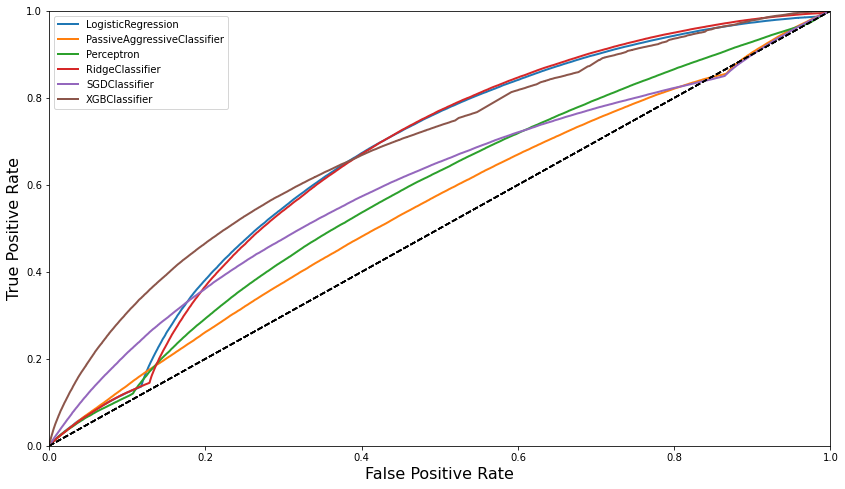

In [164]:
plt.figure(figsize=(14,8))
plot_roc_curve(fpr, tpr,label='LogisticRegression')
plot_roc_curve(fpr1, tpr1,label='PassiveAggressiveClassifier')
plot_roc_curve(fpr2, tpr2,label='Perceptron')
plot_roc_curve(fpr3, tpr3,label='RidgeClassifier')
plot_roc_curve(fpr4, tpr4,label='SGDClassifier')
plot_roc_curve(fpr6, tpr6,label='XGBClassifier')
plt.legend()

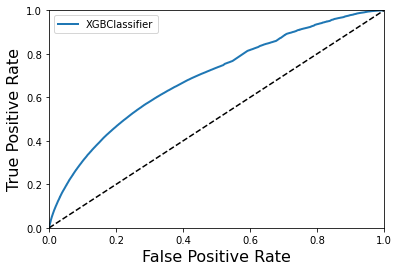

In [169]:
plot_roc_curve(fpr6, tpr6,label='XGBClassifier')
plt.legend()

In [165]:
from sklearn.metrics import roc_auc_score
print('LogisticRegression',roc_auc_score(y_label, y_scores))
print('PassiveAggressiveClassifier',roc_auc_score(y_label, y_scores1))
print('Perceptron',roc_auc_score(y_label, y_scores2))
print('RidgeClassifier',roc_auc_score(y_label, y_scores3))
print('SGDClassifier',roc_auc_score(y_label, y_scores4))
print('XGBClassifier',roc_auc_score(y_label, y_scores6))

LogisticRegression 0.6670091271452813
PassiveAggressiveClassifier 0.5485607451851857
Perceptron 0.5826701445289811
RidgeClassifier 0.6666170240524508
SGDClassifier 0.6010675918250392
XGBClassifier 0.6912215684004994


### 开始做高考试卷了 先别忘ppt上面加，我还没有搞完

In [173]:
y_pre=model.predict(data_2018)
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
print('confusion matrix:',confusion_matrix(y_2018,y_pre))
print('accuracy: %.3f'%accuracy_score(y_2018,y_pre))
print('precision: %.3f',precision_score(y_2018,y_pre))
print('recall_score: %.3f',recall_score(y_2018,y_pre))

confusion matrix: [[25235    28]
 [ 4316     3]]
accuracy: 0.853
precision: %.3f 0.0967741935483871
recall_score: %.3f 0.0006946052326927529
